In [1]:
#1. Load --> Data, Model
#2. Preprocess
#3. Split ( Train, Test)
#4. Design and Implement out model. 
#5. Train
#6. Evaluate
#7. Predict

In [2]:
import keras
from keras.datasets import mnist
import matplotlib.pyplot as plt

2025-12-17 20:50:57.739577: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-17 20:50:57.938736: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/ros/rolling/opt/rviz_ogre_vendor/lib:/opt/ros/rolling/lib/x86_64-linux-gnu:/opt/ros/rolling/lib
2025-12-17 20:50:57.938759: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2025-12-17 20:50:57.977897: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for 

In [3]:
#load 
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [4]:
train_images.shape

(60000, 28, 28)

In [5]:
test_images.shape

(10000, 28, 28)

In [6]:
train_labels.shape

(60000,)

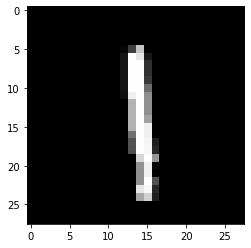

In [7]:
plt.imshow(train_images[8], cmap='gray')

In [8]:
train_labels[8]

1

In [9]:
train_labels = keras.utils.to_categorical(train_labels)
test_labels = keras.utils.to_categorical(test_labels)

In [10]:
train_labels[8]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [11]:
train_images.shape

(60000, 28, 28)

In [12]:
test_images.shape

(10000, 28, 28)

In [13]:
train_images[5]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  13,  25, 100, 122,   7,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [14]:
train_images[5].shape

(28, 28)

In [15]:
train_images = train_images.astype('float32')/255.0
test_images = test_images.astype('float32')/255.0

In [16]:
train_images[5]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [17]:
from  keras.models import Sequential
from keras import layers

In [18]:
#Design
model = Sequential()

#Feature Extraction part
model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same',activation ='relu', strides=(1, 1), input_shape=(28, 28, 1)))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation = 'relu', strides=(1, 1)))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', strides=(1, 1)))
model.add(layers.MaxPool2D(pool_size=(2, 2)))

#Classification
model.add(layers.Flatten())
model.add(layers.Dense(10, activation='softmax'))

2025-12-17 20:51:01.655903: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/ros/rolling/opt/rviz_ogre_vendor/lib:/opt/ros/rolling/lib/x86_64-linux-gnu:/opt/ros/rolling/lib
2025-12-17 20:51:01.655962: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2025-12-17 20:51:01.655996: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (mhmud): /proc/driver/nvidia/version does not exist
2025-12-17 20:51:01.656439: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

In [19]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
model.fit(train_images, train_labels, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 [==============================] - 79s 42ms/step - loss: 0.1275 - accuracy: 0.9606
Epoch 2/5
1875/1875 [==============================] - 90s 48ms/step - loss: 0.0401 - accuracy: 0.9871
Epoch 3/5
1875/1875 [==============================] - 72s 39ms/step - loss: 0.0278 - accuracy: 0.9910
Epoch 4/5
1875/1875 [==============================] - 66s 35ms/step - loss: 0.0210 - accuracy: 0.9936
Epoch 5/5
1875/1875 [==============================] - 69s 37ms/step - loss: 0.0162 - accuracy: 0.9948


In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 128)         73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 3, 3, 128)        0

In [22]:
test_los, test_acc = model.evaluate(test_images, test_labels)

313/313 [==============================] - 6s 18ms/step - loss: 0.0274 - accuracy: 0.9913


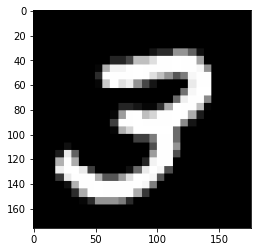

In [23]:
import cv2
test_img = cv2.imread('images.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(test_img, cmap='gray')

In [24]:
test_img_resized = cv2.resize(test_img, (28, 28))
test_img_flatten = test_img_resized.reshape(1, 28, 28, 1)
test_img_normalized = test_img_flatten.astype('float32')/255.0

In [25]:
pred = model.predict(test_img_normalized)
pred

1/1 [==============================] - 0s 149ms/step


array([[7.2196657e-14, 6.8978864e-11, 5.0254917e-10, 9.9999964e-01,
        1.0911187e-15, 1.8102011e-09, 1.0739608e-15, 1.3838984e-07,
        2.5850740e-08, 1.7938288e-07]], dtype=float32)

In [26]:
import numpy as np 

predicted_label = np.argmax(pred)
predicted_label

3

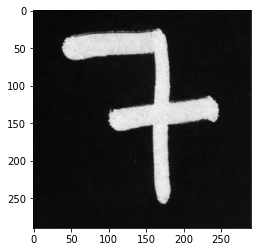

In [27]:
import cv2
test_img = cv2.imread('seven.jpg', cv2.IMREAD_GRAYSCALE)
test_image_inverted =  cv2.bitwise_not(test_img)
plt.imshow(test_image_inverted, cmap='gray')

In [28]:
test_img_resized = cv2.resize(test_image_inverted, (28, 28))
test_img_flatten = test_img_resized.reshape(1, 28, 28, 1)
test_img_normalized = test_img_flatten.astype('float32')/255.0

In [29]:
pred = model.predict(test_img_normalized)
pred

1/1 [==============================] - 0s 27ms/step


array([[3.8798824e-08, 7.5309997e-04, 1.4420314e-03, 1.3671660e-02,
        1.2860225e-03, 4.1091848e-06, 1.6410566e-05, 9.8248428e-01,
        2.7810846e-04, 6.4241089e-05]], dtype=float32)

In [30]:
import numpy as np 

predicted_label = np.argmax(pred)
predicted_label

7